# 04 · Implicit-feedback ALS

Notebook 03 trained a model to predict *ratings*. It fit ratings well (val RMSE 0.834) but ranked badly: test NDCG@10 of 0.0012 against 0.0393 for plain popularity. We found two causes:

1. Rare movies with a few high ratings got big biases and floated to the top (the median recommended movie had 6 training ratings).
2. The model never sees *which movies people chose to watch*. It only learns how they rated the ones they picked, and that choice is most of what the held-out ratings reflect.

This notebook attacks both.

## The idea
Stop predicting the rating. Predict whether the user interacted with the movie.

- Preference: `p_ui = 1` if user u has an interaction with movie i, else `0`.
- Confidence: `c_ui = 1 + α·p_ui`. Observed interactions count `1+α` times as much as unobserved cells.
- Learn user vectors `x_u` and movie vectors `y_i` by minimising

  `Σ over ALL (u,i) of  c_ui · (p_ui − x_u·y_i)²  +  λ (Σ‖x_u‖² + Σ‖y_i‖²)`

The difference from notebook 03 is the sum. Explicit MF sums over observed ratings only. This one sums over **every** user-movie pair, treating unobserved cells as weak zeros ("probably not interested, but we aren't sure"). That is how the model learns what people choose, not just how they score.

## Making it fast (Hu, Koren & Volinsky, 2008)
Summing over 20k × 17k cells sounds hopeless, but for one user the solution is `x_u = (YᵀC_uY + λI)⁻¹ YᵀC_u p_u`, and
`YᵀC_uY = YᵀY + Yᵀ(C_u − I)Y`. `YᵀY` is the same for every user, so we compute it once. `(C_u − I)` is zero except at the movies the user interacted with, so the per-user work only touches those movies.

## Choices
- **No bias terms.** Popularity is absorbed into the factors.
- **λ is constant, not scaled by rating count.** In notebook 03 the shrinkage grew with the number of ratings, so a movie with five ratings was shrunk no harder than one with five thousand. Here a rare movie has little data pulling against a fixed penalty, so it gets pulled toward zero. That targets cause 1 directly.
- **What counts as an interaction?** Two options, compared on validation:
  - `all`: every rating is an interaction ("watched it").
  - `liked`: only ratings ≥ 4. This matches how we defined a relevant item for evaluation.

## Overall Plan
1. Reference points: popularity (two versions) and the best numbers from notebook 03
2. One first run
3. Small sweep over interaction type, α, λ, k (validation only)
4. Diagnostic: are we still recommending rare movies?
5. Look inside: neighbours, one user's recommendations
6. Final test evaluation, once

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # notebooks/ -> project root -> scripts

import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from recutils import load_split, to_sets, rank_topk, evaluate_topk

NAME, K, REL, SEED = "sample_10pct", 10, 4.0, 42

S = load_split(NAME)
train, val, test = S["train"], S["val"], S["test"]
n_users = int(S["user_map"].u.max()) + 1
n_items = int(S["item_map"].i.max()) + 1
print(f"{n_users:,} users | {n_items:,} items | train {len(train):,} | val {len(val):,} | test {len(test):,}")

def seen_matrix(*dfs):
    """Sparse 0/1 matrix of (user, item) pairs the user already has; used to hide them from recommendations."""
    d = pd.concat(dfs)
    return sp.csr_matrix((np.ones(len(d), dtype=np.float32), (d.u.values, d.i.values)),
                         shape=(n_users, n_items))

seen_train = seen_matrix(train)
rel_val = to_sets(val[val.rating >= REL])
print("validation users with >=1 relevant item:", len(rel_val))

20,093 users | 17,241 items | train 2,919,680 | val 137,197 | test 137,197
validation users with >=1 relevant item: 18392


## 1 · Reference points
Two popularity baselines (everyone gets the same list, minus what they've already seen):
- by **number of ratings**, which is what notebook 02 used
- by **number of ratings ≥ 4**. Since "relevant" means a rating of at least 4, this version might be stronger.

The two explicit-MF rows are copied from notebook 03 (validation, hard-coded, not recomputed here): the best model from that sweep (λ=0.05), and the λ=0.1 model from the diagnostic cell when it was only allowed to recommend movies with at least 500 training ratings. The second row is the best ranking we got out of explicit MF, so it's a useful bar for this notebook.

In [2]:
counts       = np.bincount(train.i, minlength=n_items).astype(np.float32)
counts_liked = np.bincount(train.i[train.rating >= REL], minlength=n_items).astype(np.float32)

def eval_scores(item_scores, rel, seen):
    """Rank with one global score per item (same list for every user)."""
    score_fn = lambda ub: np.tile(item_scores, (len(ub), 1))
    return evaluate_topk(rank_topk(score_fn, rel.keys(), seen, K), rel, n_items, K)

results = {
    "popularity (all ratings)":        eval_scores(counts, rel_val, seen_train),
    "popularity (ratings >= 4)":       eval_scores(counts_liked, rel_val, seen_train),
    "[nb 03] explicit MF, lam=0.05":   {"Recall@10": 0.0015, "NDCG@10": 0.0009, "HitRate@10": 0.0054, "Coverage": 0.2635},
    "[nb 03] explicit MF, lam=0.1, >=500 only": {"Recall@10": 0.0460, "NDCG@10": 0.0349, "HitRate@10": 0.1413, "Coverage": 0.0429},
}
pd.DataFrame(results).T.round(4)

,Recall@10,NDCG@10,HitRate@10,Coverage
popularity (all ratings),0.0574,0.0415,0.1620,0.0137
popularity (ratings >= 4),0.0576,0.0419,0.1633,0.0139
"[nb 03] explicit MF, lam=0.05",0.0015,0.0009,0.0054,0.2635
"[nb 03] explicit MF, lam=0.1, >=500 only",0.0460,0.0349,0.1413,0.0429


## 2 · The model code

**Half-step.** For one row (a user, or a movie in the other half-step), `Yj` holds the fixed vectors of the items that row interacted with, and `c−1 = α` for each of them (the `data` of the sparse matrix). Then

`A = YᵀY + Yjᵀ diag(c−1) Yj + λI`   and   `b = Yjᵀ c`   (preference is 1 on observed cells, so `Yᵀ C p` reduces to `Yjᵀ c`)

and the new vector is `solve(A, b)`. Rows with no interactions get a zero vector.

Ranking score for a user is just `x_u · y_i`. Already-seen movies are masked out by `rank_topk`, same as before.

In [3]:
def _implicit_half_step(M, Y, lam):
    """One side of implicit ALS. M: CSR (rows to solve x fixed side) whose data = confidence - 1."""
    n_rows, k = M.shape[0], Y.shape[1]
    YtY = Y.T @ Y
    reg = lam * np.eye(k)
    out = np.zeros((n_rows, k))
    indptr, indices, data = M.indptr, M.indices, M.data
    for r in range(n_rows):
        s, e = indptr[r], indptr[r + 1]
        if s == e:
            continue
        Yj  = Y[indices[s:e]]
        cm1 = data[s:e]
        A = YtY + (Yj.T * cm1) @ Yj + reg
        b = Yj.T @ (cm1 + 1.0)
        out[r] = np.linalg.solve(A, b)
    return out


def fit_implicit(df, mode="liked", k=32, alpha=20.0, lam=20.0, n_iter=10,
                 eval_fn=None, eval_every=0, seed=SEED):
    assert mode in ("all", "liked")
    d = df[df.rating >= REL] if mode == "liked" else df
    C  = sp.csr_matrix((np.full(len(d), float(alpha)), (d.u.values, d.i.values)), shape=(n_users, n_items))
    Ct = C.T.tocsr()
    rng = np.random.default_rng(seed)
    Q = rng.normal(0, 0.1, (n_items, k))
    hist, t0 = [], time.time()
    for it in range(1, n_iter + 1):
        P = _implicit_half_step(C,  Q, lam)
        Q = _implicit_half_step(Ct, P, lam)
        if eval_fn and eval_every and (it % eval_every == 0 or it == n_iter):
            hist.append({"iter": it, "sec": round(time.time() - t0), **eval_fn(P, Q)})
    return {"P": P, "Q": Q}, pd.DataFrame(hist)


def make_eval(rel, seen_csr):
    def f(P, Q):
        Q32 = Q.astype(np.float32)
        score_fn = lambda ub: P[ub].astype(np.float32) @ Q32.T
        return evaluate_topk(rank_topk(score_fn, rel.keys(), seen_csr, K), rel, n_items, K)
    return f

eval_val = make_eval(rel_val, seen_train)

## 3 · First run
Starting point: `liked` interactions, k=32, α=20, λ=20, 10 iterations. These are reasonable defaults, not tuned values. Ranking metrics are logged every 2 iterations so we can see whether 10 is enough.

In [4]:
m1, h1 = fit_implicit(train, "liked", k=32, alpha=20, lam=20, n_iter=10, eval_fn=eval_val, eval_every=2)
h1.round(4)

,iter,sec,Recall@10,NDCG@10,HitRate@10,Coverage
0,2,3,0.1041,0.0734,0.2723,0.1023
1,4,10,0.1090,0.0775,0.2857,0.1165
2,6,16,0.1097,0.0783,0.2889,0.1209
3,8,23,0.1100,0.0788,0.2901,0.1231
4,10,29,0.1103,0.0789,0.2895,0.1249


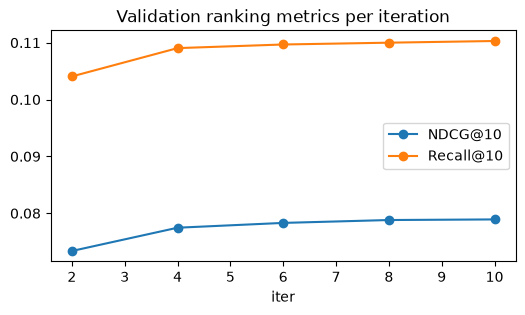

,Recall@10,NDCG@10,HitRate@10,Coverage
popularity (all ratings),0.0574,0.0415,0.1620,0.0137
popularity (ratings >= 4),0.0576,0.0419,0.1633,0.0139
"[nb 03] explicit MF, lam=0.05",0.0015,0.0009,0.0054,0.2635
"[nb 03] explicit MF, lam=0.1, >=500 only",0.0460,0.0349,0.1413,0.0429
"implicit ALS, liked, k=32 a=20 lam=20",0.1103,0.0789,0.2895,0.1249


In [5]:
h1.plot(x="iter", y=["NDCG@10", "Recall@10"], marker="o", figsize=(6, 3), title="Validation ranking metrics per iteration")
plt.show()

results["implicit ALS, liked, k=32 a=20 lam=20"] = h1.iloc[-1].drop(["iter", "sec"]).to_dict()
pd.DataFrame(results).T.round(4)

## 4 · Small sweep (validation only)
The first row is the run above. The others change one thing at a time from it, which is cheap but ignores interactions between settings (α and λ in particular trade off against each other). Treat the winner as "good", not "optimal", and if it sits at the edge of the grid (α = 5 or 60, λ = 5 or 80), extend the grid before trusting it.

- `mode`: does counting every rating as an interaction beat counting only the liked ones?
- `alpha`: how much more an observed interaction matters than an unobserved cell.
- `lam`: regularisation strength.
- `k`: number of latent factors.

Selection is by validation NDCG@10.

In [6]:
all_cfgs = [
    # mode,   k,  alpha, lam
    ("liked", 32, 20, 20),     # = first run
    ("all",   32, 20, 20),
    ("liked", 32,  5, 20),
    ("liked", 32, 60, 20),
    ("liked", 32, 20,  5),
    ("liked", 32, 20, 80),
    ("liked", 64, 20, 20),
]
models, rows = {0: m1}, [{"id": 0, "mode": "liked", "k": 32, "alpha": 20, "lam": 20,
                          **h1.iloc[-1].drop(["iter", "sec"]).to_dict()}]

for cid, (mode, k, alpha, lam) in enumerate(all_cfgs):
    if cid == 0:
        continue
    t = time.time()
    m, h = fit_implicit(train, mode, k, alpha, lam, n_iter=10, eval_fn=eval_val, eval_every=10)
    models[cid] = m
    rows.append({"id": cid, "mode": mode, "k": k, "alpha": alpha, "lam": lam,
                 **h.iloc[-1].drop(["iter", "sec"]).to_dict()})
    print(f"id={cid} {mode:>5} k={k} alpha={alpha} lam={lam}: {time.time()-t:.0f}s")

sweep = pd.DataFrame(rows).sort_values("NDCG@10", ascending=False).reset_index(drop=True)
sweep.round(4)

id=1   all k=32 alpha=20 lam=20: 24s
id=2 liked k=32 alpha=5 lam=20: 19s
id=3 liked k=32 alpha=60 lam=20: 19s
id=4 liked k=32 alpha=20 lam=5: 18s
id=5 liked k=32 alpha=20 lam=80: 19s
id=6 liked k=64 alpha=20 lam=20: 35s


,id,mode,k,alpha,lam,Recall@10,NDCG@10,HitRate@10,Coverage
0,2,liked,32,5,20,0.1190,0.0870,0.3092,0.0861
1,6,liked,64,20,20,0.1188,0.0832,0.3068,0.1402
2,5,liked,32,20,80,0.1121,0.0805,0.2936,0.1158
3,0,liked,32,20,20,0.1103,0.0789,0.2895,0.1249
4,4,liked,32,20,5,0.1101,0.0786,0.2884,0.1272
5,3,liked,32,60,20,0.0963,0.0665,0.2555,0.1777
6,1,all,32,20,20,0.0834,0.0577,0.2292,0.1850


## 5 · Is the rare-movie problem gone?
Same diagnostic as notebook 03, run on the best configuration from the sweep. In notebook 03 the median recommended movie had **6** training ratings and **83%** of recommendations had fewer than 20 (catalogue median: 23).

In [7]:
best_id = int(sweep.iloc[0]["id"])
print("best on validation:", all_cfgs[best_id])
P, Q = models[best_id]["P"], models[best_id]["Q"]
Q32 = Q.astype(np.float32)

ranked = rank_topk(lambda ub: P[ub].astype(np.float32) @ Q32.T, rel_val.keys(), seen_train, K)
n_train = np.bincount(train.i, minlength=n_items)
rec_counts = np.array([n_train[i] for r in ranked.values() for i in r])

print("median train ratings of recommended movies:", int(np.median(rec_counts)))
print("share of recommendations with < 20 train ratings:", round(float((rec_counts < 20).mean()), 3))
print("median train ratings across the catalogue:", int(np.median(n_train)))
print("distinct movies recommended:", len(set(i for r in ranked.values() for i in r)))

best on validation: ('liked', 32, 5, 20)
median train ratings of recommended movies: 3619
share of recommendations with < 20 train ratings: 0.0
median train ratings across the catalogue: 23
distinct movies recommended: 1485


## 6 · What did it learn?
Same checks as notebook 03: nearest neighbours in factor space (only movies with at least 50 training ratings), and one user's recommendations next to what they rated highly. It's the same user as in notebook 03, so the two lists can be compared directly.

In [8]:
movies = pd.read_parquet(Path("../data/interim") / NAME / "movies.parquet")
meta   = S["item_map"].merge(movies, on="movieId", how="left").set_index("i").sort_index()
Qn     = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-9)

def similar(title_part, n=6, min_count=50):
    i = meta.index[meta.title.str.contains(title_part, regex=False)][0]
    sims = Qn @ Qn[i]
    sims[n_train < min_count] = -1
    sims[i] = -1
    top = np.argsort(-sims)[:n]
    print(f"\nClosest to: {meta.loc[i, 'title']}")
    return meta.loc[top, ["title", "genres"]].assign(cosine=sims[top].round(3))

similar("Toy Story (1995)")


Closest to: Toy Story (1995)


,title,genres,cosine
i,,,
2817,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.846
350,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.791
559,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.779
997,Willy Wonka & the Chocolate Factory (1971),Children|Comedy|Fantasy|Musical,0.753
3868,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.752
4396,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.751


In [9]:
similar("Matrix, The (1999)")


Closest to: Matrix, The (1999)


,title,genres,cosine
i,,,
2675,Fight Club (1999),Action|Crime|Drama|Thriller,0.920
1815,Saving Private Ryan (1998),Action|Drama|War,0.896
3207,Gladiator (2000),Action|Adventure|Drama,0.882
1101,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.881
2491,"Sixth Sense, The (1999)",Drama|Horror|Mystery,0.879
1099,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.871


In [10]:
similar("Pulp Fiction")


Closest to: Pulp Fiction (1994)


,title,genres,cosine
i,,,
563,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.964
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.955
46,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,0.937
305,"Shawshank Redemption, The (1994)",Crime|Drama,0.921
506,Schindler's List (1993),Drama|War,0.875
342,Forrest Gump (1994),Comedy|Drama|Romance|War,0.865


In [11]:
def show_user(u, model, n=10):
    s = model["P"][u] @ model["Q"].T
    s[seen_train[u].indices] = -np.inf
    rec  = np.argsort(-s)[:n]
    held = set(val[(val.u == u) & (val.rating >= REL)].i)
    print("Rated highest in train:")
    for t in meta.loc[train[train.u == u].nlargest(n, "rating").i, "title"]:
        print("  " + t)
    print("\nTop recommendations (✓ = user later rated it ≥ 4 in validation):")
    for i in rec:
        print(("✓ " if i in held else "  ") + meta.loc[i, "title"])

show_user(list(rel_val)[0], models[best_id])

Rated highest in train:
  Blade Runner (1982)
  Emma (1996)
  Shakespeare in Love (1998)
  Doom Generation, The (1995)
  Eat Drink Man Woman (Yin shi nan nu) (1994)
  Election (1999)
  Elizabeth (1998)
  Star Wars: Episode IV - A New Hope (1977)
  Star Wars: Episode V - The Empire Strikes Back (1980)
  Dark City (1998)

Top recommendations (✓ = user later rated it ≥ 4 in validation):
  2001: A Space Odyssey (1968)
  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
  L.A. Confidential (1997)
  Godfather, The (1972)
  One Flew Over the Cuckoo's Nest (1975)
  Annie Hall (1977)
  Clockwork Orange, A (1971)
  Chinatown (1974)
  Groundhog Day (1993)
  Alien (1979)


## 7 · Final test evaluation
The configuration is read straight from the sweep table (best validation NDCG@10), so there's no value to type in by hand. We refit on train + validation, hide both from the recommendations, and score on test one time. The explicit-MF row is copied from notebook 03's test table (λ=0.05).

In [12]:
mode, k, alpha, lam = all_cfgs[best_id]
print("selected on validation:", dict(mode=mode, k=k, alpha=alpha, lam=lam))

full     = pd.concat([train, val])
seen_tv  = seen_matrix(train, val)
rel_test = to_sets(test[test.rating >= REL])

final, _  = fit_implicit(full, mode, k, alpha, lam, n_iter=10)
imp_test  = make_eval(rel_test, seen_tv)(final["P"], final["Q"])

counts_tv = np.bincount(full.i, minlength=n_items).astype(np.float32)
liked_tv  = np.bincount(full.i[full.rating >= REL], minlength=n_items).astype(np.float32)

test_table = pd.DataFrame({
    "popularity (all ratings)":   eval_scores(counts_tv, rel_test, seen_tv),
    "popularity (ratings >= 4)":  eval_scores(liked_tv, rel_test, seen_tv),
    "[nb 03] explicit MF":        {"Recall@10": 0.0020, "NDCG@10": 0.0012, "HitRate@10": 0.0072, "Coverage": 0.2628},
    f"implicit ALS ({mode}, k={k}, a={alpha}, lam={lam})": imp_test,
}).T.round(4)
test_table

selected on validation: {'mode': 'liked', 'k': 32, 'alpha': 5, 'lam': 20}


,Recall@10,NDCG@10,HitRate@10,Coverage
popularity (all ratings),0.0531,0.0393,0.1562,0.0147
popularity (ratings >= 4),0.0524,0.0396,0.1564,0.0148
[nb 03] explicit MF,0.0020,0.0012,0.0072,0.2628
"implicit ALS (liked, k=32, a=5, lam=20)",0.1109,0.0821,0.2980,0.0878


In [13]:
Path("../models").mkdir(exist_ok=True)
np.savez("../models/als_implicit.npz", **final)

## Findings

_Fill this in after running. Replace the blanks with your own numbers and wording._

| Model | Recall@10 | NDCG@10 | HitRate@10 | Coverage |
|---|---|---|---|---|
| Popularity (all ratings), test | | | | |
| Popularity (ratings ≥ 4), test | | | | |
| Explicit MF (notebook 03), test | 0.0020 | 0.0012 | 0.0072 | 0.263 |
| Implicit ALS, test | | | | |

**Did it fix the ranking?** _Compare implicit ALS with both popularity rows. Say plainly if it beats popularity or not, and by how much._

**What did the sweep say?** _Did `all` or `liked` win? Did α or λ end up at the edge of the grid?_

**Rare movies:** _Median training ratings of recommended movies went from 6 (notebook 03) to ___. Share with fewer than 20: ___ (was 83%)._

**What the factors look like:** _Are the neighbours and the sample user's recommendations better or worse than in notebook 03?_

**Next:** content features (genres, year, tags, TMDB) and the hybrid, starting with the movies that have few or no ratings.